# Clasificación Binaria Supervisada: Predicción de Pago de Préstamos

**Dataset:** `train.csv` / `test.csv`  
**Tarea:** Clasificación binaria — ¿El cliente pagará el préstamo? (`loan_paid_back`)  

---



## 1. Librerías

In [ ]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluación ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# ── Validación cruzada e hiperparámetros ─────────────────────────────────────
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split
)
from sklearn.base import clone
from sklearn.metrics import auc

# ── Interpretabilidad ─────────────────────────────────────────────────────────
import shap

# ── Configuración global de visualización ────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.titlesize": 13, "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga y Exploración de Datos

In [ ]:
# ── Cargar los conjuntos de datos ─────────────────────────────────────────────
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print(f"Forma del conjunto de ENTRENAMIENTO : {train_df.shape}")
print(f"Forma del conjunto de PRUEBA        : {test_df.shape}")
print("─" * 60)
print("Columnas de ENTRENAMIENTO:", train_df.columns.tolist())
print("Columnas de PRUEBA       :", test_df.columns.tolist())
print("─" * 60)

TEST_HAS_TARGET = "loan_paid_back" in test_df.columns
print(f"¿El test.csv contiene 'loan_paid_back'?  →  {TEST_HAS_TARGET}")
if not TEST_HAS_TARGET:
    print(">> El test set NO tiene etiquetas: NO se calculará ROC-AUC sobre él.")
    print(">> El ROC-AUC final se calculará con predicciones out-of-fold (OOF).")

Forma del conjunto de ENTRENAMIENTO : (593994, 13)
Forma del conjunto de PRUEBA        : (254569, 12)
────────────────────────────────────────────────────────────
Columnas de ENTRENAMIENTO: ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back']
Columnas de PRUEBA       : ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
────────────────────────────────────────────────────────────
¿El test.csv contiene 'loan_paid_back'?  →  False
>> El test set NO tiene etiquetas: NO se calculará ROC-AUC sobre él.
>> El ROC-AUC final se calculará con predicciones out-of-fold (OOF).


In [ ]:
# ── Vista previa ──────────────────────────────────────────────────────────────
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.9900,0.0840,736,2528.4200,13.6700,Female,Single,High School,Self-employed,Other,C3,1.0000
1,1,22108.0200,0.1660,636,4593.1000,12.9200,Male,Married,Master's,Employed,Debt consolidation,D3,0.0000
2,2,49566.2000,0.0970,694,17005.1500,9.7600,Male,Single,High School,Employed,Debt consolidation,C5,1.0000
3,3,46858.2500,0.0650,533,4682.4800,16.1000,Female,Single,High School,Employed,Debt consolidation,F1,1.0000
4,4,25496.7000,0.0530,665,12184.4300,10.2100,Male,Married,High School,Employed,Other,D1,1.0000


In [ ]:
# ── Tipos de datos y valores faltantes ────────────────────────────────────────
info = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "n_nulos": train_df.isnull().sum(),
    "%_nulos": (train_df.isnull().mean() * 100).round(2),
    "n_unicos": train_df.nunique(),
})
info

,dtype,n_nulos,%_nulos,n_unicos
id,int64,0,0.0000,593994
annual_income,float64,0,0.0000,119728
debt_to_income_ratio,float64,0,0.0000,526
credit_score,int64,0,0.0000,399
loan_amount,float64,0,0.0000,111570
interest_rate,float64,0,0.0000,1454
gender,str,0,0.0000,3
marital_status,str,0,0.0000,4
education_level,str,0,0.0000,5
employment_status,str,0,0.0000,5


### 2.2 Análisis de la Variable Objetivo

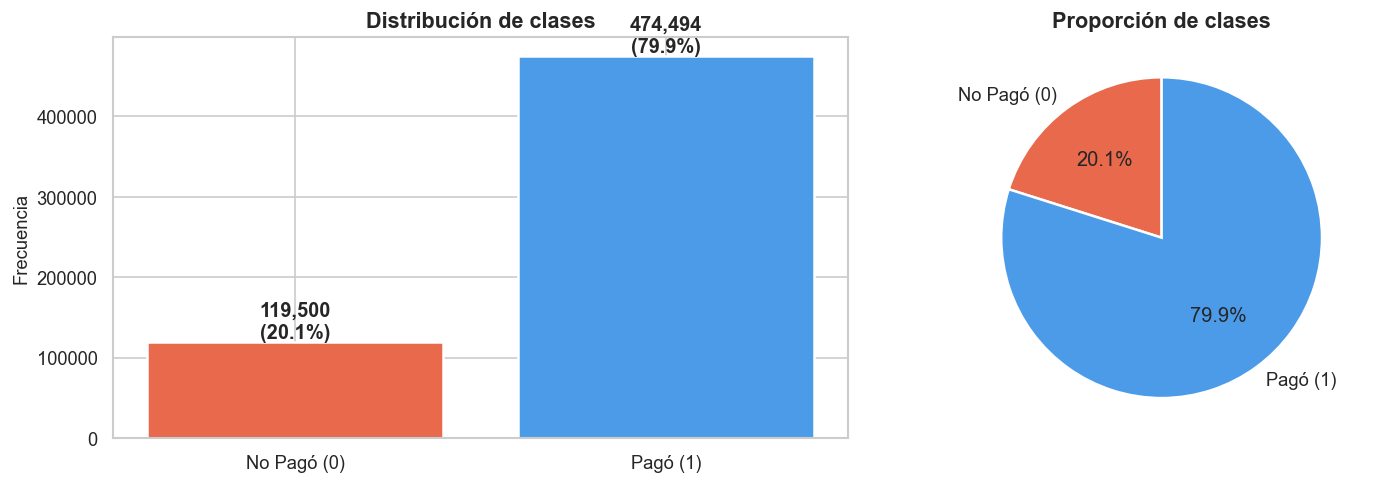

In [ ]:
# ── Distribución de la variable objetivo ─────────────────────────────────────
target_counts = train_df["loan_paid_back"].value_counts().sort_index()
target_pct    = train_df["loan_paid_back"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
colors = ["#E8694C", "#4C9BE8"]
ax[0].bar(["No Pagó (0)", "Pagó (1)"], target_counts.values, color=colors,
          edgecolor="white", linewidth=1.5)
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v, f"{v:,}\n({target_pct.values[i]:.1f}%)", ha="center", va="bottom", fontweight="bold")
ax[0].set_title("Distribución de clases", fontweight="bold")
ax[0].set_ylabel("Frecuencia")
ax[1].pie(target_counts.values, labels=["No Pagó (0)", "Pagó (1)"], colors=colors,
          autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax[1].set_title("Proporción de clases", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
# ── Estadísticas descriptivas de variables numéricas ─────────────────────────
NUMERIC_CONT = ["annual_income", "debt_to_income_ratio", "credit_score",
                "loan_amount", "interest_rate"]
train_df[NUMERIC_CONT].describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.0000,48212.2030,26711.9421,6002.4300,27934.4000,46557.6800,60981.3200,393381.7400
debt_to_income_ratio,593994.0000,0.1207,0.0686,0.0110,0.0720,0.0960,0.1560,0.6270
credit_score,593994.0000,680.9160,55.4250,395.0000,646.0000,682.0000,719.0000,849.0000
loan_amount,593994.0000,15020.2976,6926.5306,500.0900,10279.6200,15000.2200,18858.5800,48959.9500
interest_rate,593994.0000,12.3563,2.0090,3.2000,10.9900,12.3700,13.6800,20.9900


### 2.3 Distribución de Variables Numéricas por Clase


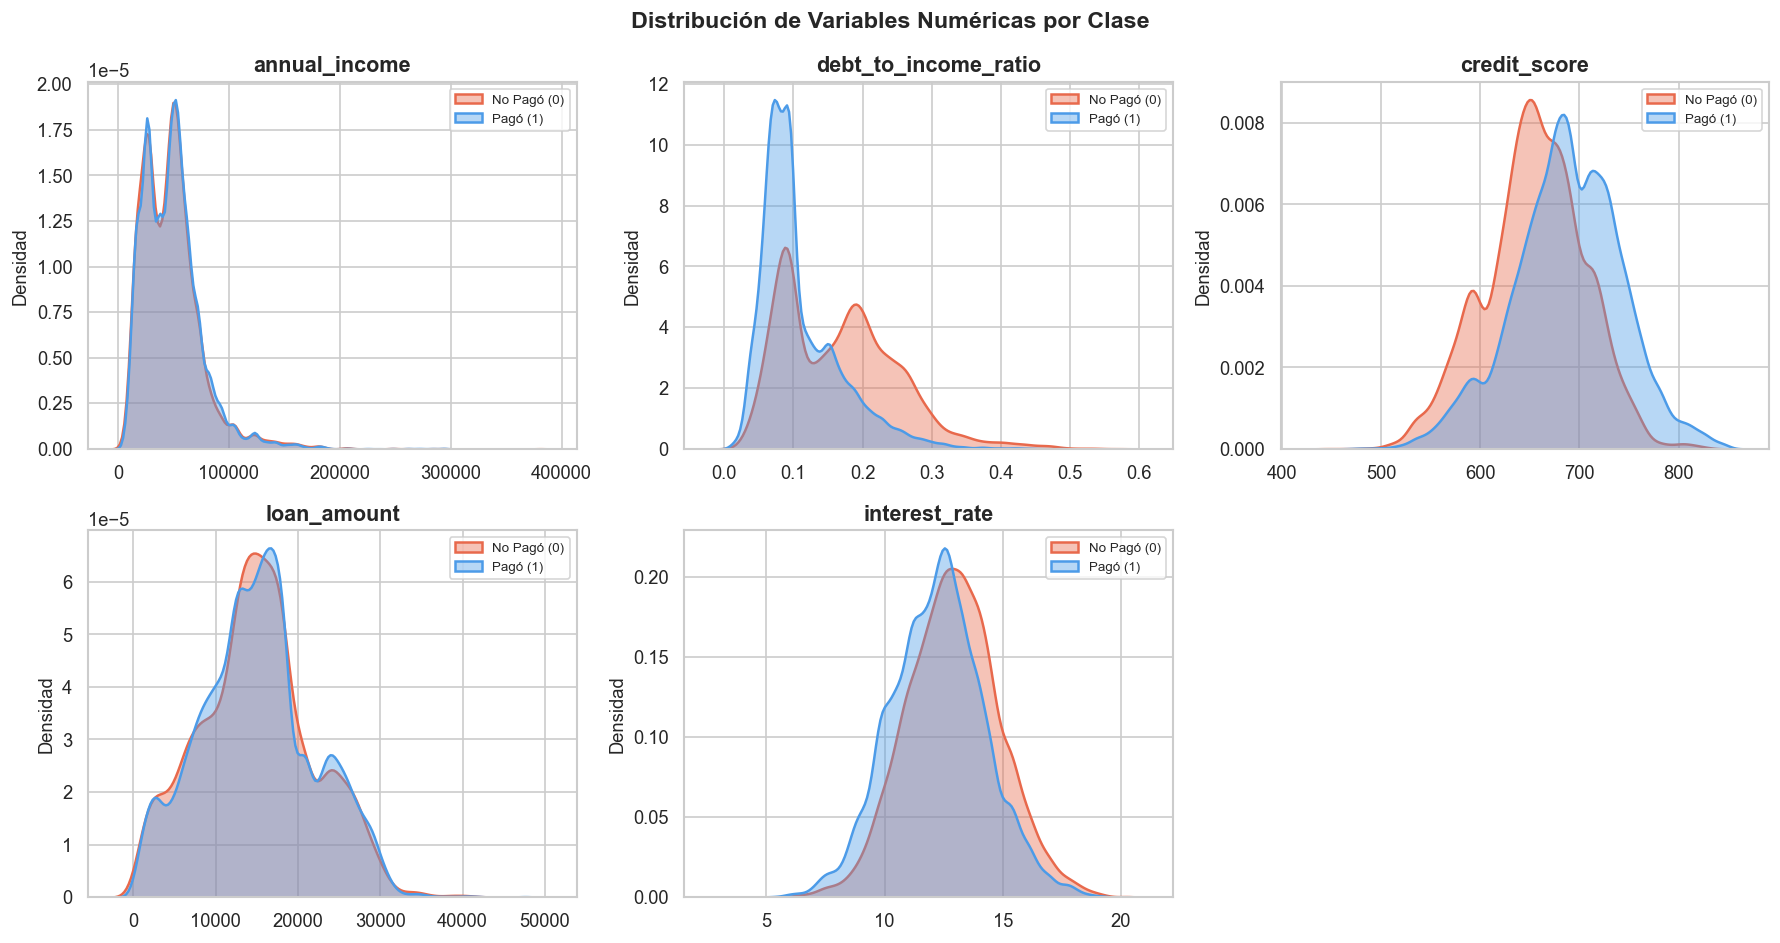

In [ ]:
# ── Distribución de variables numéricas por clase ─────────────────────────────
plot_sample = train_df.sample(min(50_000, len(train_df)), random_state=RANDOM_STATE)
palette = {0: "#E8694C", 1: "#4C9BE8"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col in zip(axes, NUMERIC_CONT):
    for cls, color in palette.items():
        sns.kdeplot(data=plot_sample[plot_sample["loan_paid_back"] == cls],
                    x=col, ax=ax, fill=True, alpha=0.4, color=color, linewidth=1.5,
                    label=("No Pagó (0)" if cls == 0 else "Pagó (1)"))
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
axes[-1].axis("off")   # sexto panel vacío (solo hay 5 variables numéricas)
fig.suptitle("Distribución de Variables Numéricas por Clase",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 3. Preprocesamiento y Conteo Correcto de *Features*

In [ ]:
# ── Definir codificación ──────────────────────────────────────────────────────
GRADE_ORDER = [f"{l}{n}" for l in "ABCDEF" for n in range(1, 6)]   # A1..F5 (ordinal)
GRADE_MAP   = {g: i for i, g in enumerate(GRADE_ORDER)}

CATEGORICAL_COLS = ["gender", "marital_status", "education_level",
                    "employment_status", "loan_purpose"]

ID_COL, TARGET_COL = "id", "loan_paid_back"

def preprocess(df, reference_columns=None):
    '''Codifica el dataframe: ordinal para grade_subgrade y one-hot para nominales.
    No realiza ningun ajuste dependiente de los datos (sin fuga de informacion):
    el escalado y la expansion polinomica se hacen DENTRO de los pipelines/CV.'''
    df = df.copy()
    df["grade_subgrade"] = df["grade_subgrade"].map(GRADE_MAP)          # ordinal
    df = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=False) # one-hot
    if reference_columns is not None:
        df = df.reindex(columns=reference_columns, fill_value=0)        # alinear test
    return df.astype(float)

print("11 features predictivas originales:")
print("  Numéricas continuas (5):", NUMERIC_CONT)
print("  Categóricas nominales (5):", CATEGORICAL_COLS)
print("  Categórica ordinal (1): ['grade_subgrade']")

11 features predictivas originales:
  Numéricas continuas (5): ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
  Categóricas nominales (5): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']
  Categórica ordinal (1): ['grade_subgrade']


In [ ]:
X_full = preprocess(train_df.drop(columns=[ID_COL, TARGET_COL]))
y_full = train_df[TARGET_COL].astype(int)
X_test = preprocess(test_df.drop(columns=[ID_COL]),
                    reference_columns=X_full.columns.tolist())

REST_COLS = [c for c in X_full.columns if c not in NUMERIC_CONT]   # ordinal + dummies

print(f"Features ORIGINALES predictivas : 11")
print(f"Columnas tras one-hot encoding  : {X_full.shape[1]}  "
      f"(5 numéricas + 1 ordinal + {X_full.shape[1]-6} dummies)")
print(f"X_full : {X_full.shape}   |   y_full : {y_full.shape}")
print(f"X_test : {X_test.shape}   (sin etiquetas)")

Features ORIGINALES predictivas : 11
Columnas tras one-hot encoding  : 31  (5 numéricas + 1 ordinal + 25 dummies)
X_full : (593994, 31)   |   y_full : (593994,)
X_test : (254569, 31)   (sin etiquetas)


### 3.2 Muestreo estratificado para el entrenamiento

In [ ]:
SAMPLE_SIZE = None   # none para entrenar con todo el dataset o se puede configurar

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X_full):
    X, _, y, _ = train_test_split(
        X_full, y_full, train_size=SAMPLE_SIZE,
        stratify=y_full, random_state=RANDOM_STATE)
    print(f"Muestra estratificada: {X.shape[0]:,} filas "
          f"(proporción clase 1 = {y.mean():.3f})")
else:
    X, y = X_full, y_full
    print(f"Dataset completo: {X.shape[0]:,} filas (proporción clase 1 = {y.mean():.3f})")

Dataset completo: 593,994 filas (proporción clase 1 = 0.799)


## 4. Validación Cruzada y Aclaración Metodológica

In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
scale_pw = n_neg / n_pos          
print(f"CV: StratifiedKFold(5) | scale_pos_weight (XGB) = {scale_pw:.4f}")

def cv_results_table(gs, param_cols, top=8):
    r = pd.DataFrame(gs.cv_results_)
    cols = [f"param_{p}" for p in param_cols] + \
           ["mean_test_score", "std_test_score", "rank_test_score"]
    r = r[cols].sort_values("rank_test_score").head(top).reset_index(drop=True)
    r.columns = param_cols + ["ROC-AUC media (CV)", "Desv. estándar", "Rank"]
    return r

CV: StratifiedKFold(5) | scale_pos_weight (XGB) = 0.2518


## 5. Optimización con `GridSearchCV`

### 5.1 Regresión Logística con `PolynomialFeatures`

In [ ]:
pre_lr = ColumnTransformer([
    ("num", Pipeline([
        ("poly",   PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),
    ]), NUMERIC_CONT),
    ("rest", StandardScaler(), REST_COLS),
])

pipe_lr = Pipeline([
    ("pre",    pre_lr),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs")),
])

param_grid_lr = {
    "pre__num__poly__degree": [1, 2, 3],   # grado 1 = sin expansión
    "logreg__C":              [0.01, 0.1, 1.0, 10.0],
    "logreg__penalty":        ["l2"],         # solver lbfgs solo admite l2
}

print("Ejecutando GridSearchCV — Regresión Logística (Poly)...")
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv_strategy,
                     scoring="roc_auc", n_jobs=1, refit=True)
gs_lr.fit(X, y)
print(f"Mejores parámetros : {gs_lr.best_params_}")
print(f"Mejor ROC-AUC (CV) : {gs_lr.best_score_:.4f}")

Ejecutando GridSearchCV — Regresión Logística (Poly)...
Mejores parámetros : {'logreg__C': 10.0, 'logreg__penalty': 'l2', 'pre__num__poly__degree': 3}
Mejor ROC-AUC (CV) : 0.9114


In [ ]:
lr_cv_results = pd.DataFrame(gs_lr.cv_results_)

check_lr = lr_cv_results[
    [
        "param_pre__num__poly__degree",
        "param_logreg__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

check_lr = check_lr.sort_values(
    ["param_pre__num__poly__degree", "param_logreg__C"]
)

check_lr.columns = [
    "Grado polinómico",
    "C",
    "ROC-AUC media CV",
    "Desv. estándar",
    "Ranking"
]

display(
    check_lr.style
    .format({
        "ROC-AUC media CV": "{:.4f}",
        "Desv. estándar": "{:.4f}"
    })
    .background_gradient(subset=["ROC-AUC media CV"], cmap="YlGnBu")
    .hide(axis="index")
)

Grado polinómico,C,ROC-AUC media CV,Desv. estándar,Ranking
1,0.010000,0.9102,0.0008,9
1,0.100000,0.9102,0.0008,12
1,1.000000,0.9102,0.0008,10
1,10.000000,0.9102,0.0008,11
2,0.010000,0.9109,0.0008,8
2,0.100000,0.9111,0.0008,7
2,1.000000,0.9111,0.0008,6
2,10.000000,0.9112,0.0008,5
3,0.010000,0.9113,0.0008,4
3,0.100000,0.9114,0.0008,2


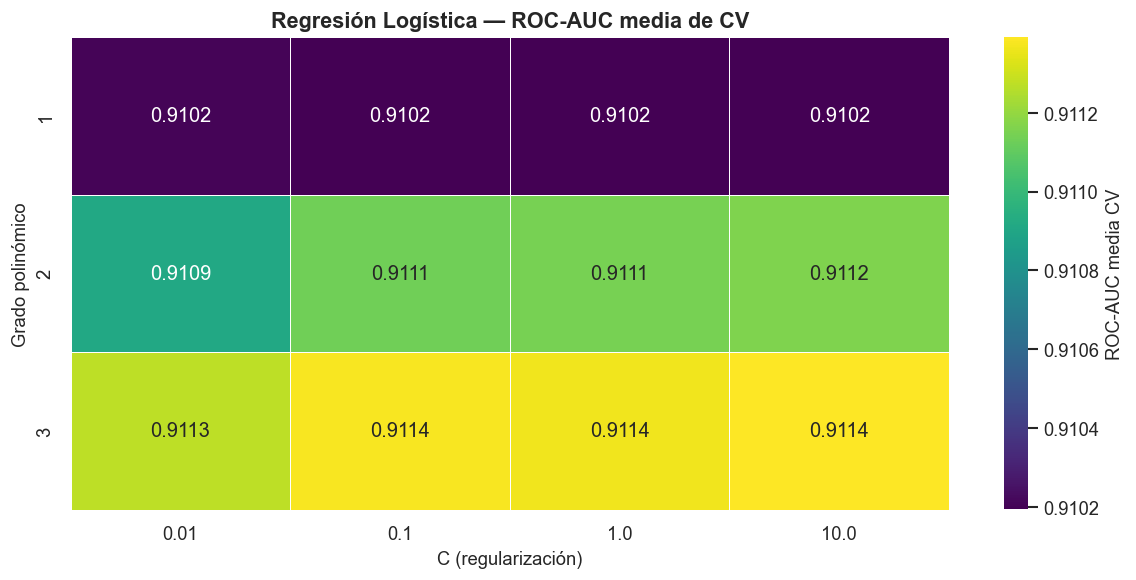

In [ ]:
# ── Heatmap Regresión Logística — ROC-AUC media CV ───────────────────────────

lr_cv_results = pd.DataFrame(gs_lr.cv_results_)

# Convertir parámetros a tipo numérico
lr_cv_results["param_pre__num__poly__degree"] = (
    lr_cv_results["param_pre__num__poly__degree"].astype(int)
)

lr_cv_results["param_logreg__C"] = (
    lr_cv_results["param_logreg__C"].astype(float)
)

# Crear tabla pivote
lr_pivot = lr_cv_results.pivot_table(
    index="param_pre__num__poly__degree",
    columns="param_logreg__C",
    values="mean_test_score",
    aggfunc="mean"
)

# Orden esperado
degrees_order = sorted(param_grid_lr["pre__num__poly__degree"])
c_order = sorted(param_grid_lr["logreg__C"])

lr_pivot = lr_pivot.reindex(index=degrees_order, columns=c_order)

# Etiquetas personalizadas
annot_labels = lr_pivot.copy().astype(object)

for degree in annot_labels.index:
    for c_value in annot_labels.columns:
        value = lr_pivot.loc[degree, c_value]
        if pd.isna(value):
            annot_labels.loc[degree, c_value] = "Falló"
        else:
            annot_labels.loc[degree, c_value] = f"{value:.4f}"

plt.figure(figsize=(10, 5))

ax = sns.heatmap(
    lr_pivot,
    annot=annot_labels,
    fmt="",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "ROC-AUC media CV"}
)

ax.set_title("Regresión Logística — ROC-AUC media de CV", fontweight="bold")
ax.set_xlabel("C (regularización)")
ax.set_ylabel("Grado polinómico")

plt.tight_layout()
plt.show()

In [ ]:
# ── Tabla de resultados de GridSearchCV — Regresión Logística ─────────────────
tbl_lr = cv_results_table(gs_lr, ["pre__num__poly__degree", "logreg__C", "logreg__penalty"])
(tbl_lr.style
    .format({"ROC-AUC media (CV)": "{:.4f}", "Desv. estándar": "{:.4f}"})
    .background_gradient(subset=["ROC-AUC media (CV)"], cmap="Blues")
    .set_caption("GridSearchCV — Regresión Logística (mejores combinaciones)")
    .hide(axis="index"))

pre__num__poly__degree,logreg__C,logreg__penalty,ROC-AUC media (CV),Desv. estándar,Rank
3,10.000000,l2,0.9114,0.0007,1
3,0.100000,l2,0.9114,0.0008,2
3,1.000000,l2,0.9114,0.0007,3
3,0.010000,l2,0.9113,0.0008,4
2,10.000000,l2,0.9112,0.0008,5
2,1.000000,l2,0.9111,0.0008,6
2,0.100000,l2,0.9111,0.0008,7
2,0.010000,l2,0.9109,0.0008,8


### 5.2 Random Forest

In [ ]:
# ── GridSearchCV — Random Forest ──────────────────────────────────────────────
param_grid_rf = {"n_estimators": [200, 250, 300], "max_depth": [4, 6, 8]}

print("Ejecutando GridSearchCV — Random Forest...")
gs_rf = GridSearchCV(
    RandomForestClassifier(min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=1),
    param_grid_rf, cv=cv_strategy, scoring="roc_auc", n_jobs=-1, refit=True)
gs_rf.fit(X, y)
print(f"Mejores parámetros : {gs_rf.best_params_}")
print(f"Mejor ROC-AUC (CV) : {gs_rf.best_score_:.4f}")

Ejecutando GridSearchCV — Random Forest...
Mejores parámetros : {'max_depth': 8, 'n_estimators': 250}
Mejor ROC-AUC (CV) : 0.9083


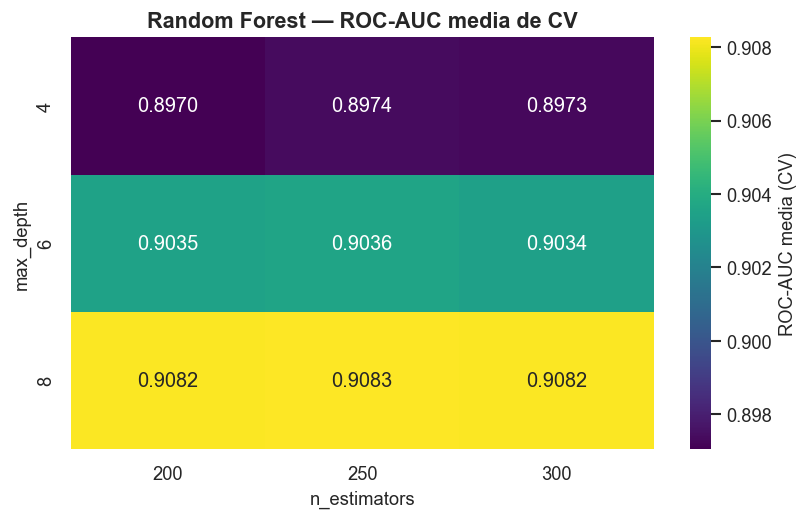

In [ ]:
# ── Heatmap — Random Forest ───────────────────────────────────────────────────
res_rf = pd.DataFrame(gs_rf.cv_results_)
pivot_rf = res_rf.pivot_table(index="param_max_depth", columns="param_n_estimators",
                              values="mean_test_score")
plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot_rf, annot=True, fmt=".4f", cmap="viridis",
            cbar_kws={"label": "ROC-AUC media (CV)"})
plt.title("Random Forest — ROC-AUC media de CV", fontweight="bold")
plt.xlabel("n_estimators"); plt.ylabel("max_depth")
plt.tight_layout(); plt.show()

In [ ]:
tbl_rf = cv_results_table(gs_rf, ["n_estimators", "max_depth"])
(tbl_rf.style
    .format({"ROC-AUC media (CV)": "{:.4f}", "Desv. estándar": "{:.4f}"})
    .background_gradient(subset=["ROC-AUC media (CV)"], cmap="Blues")
    .set_caption("GridSearchCV — Random Forest (mejores combinaciones)")
    .hide(axis="index"))

n_estimators,max_depth,ROC-AUC media (CV),Desv. estándar,Rank
250,8,0.9083,0.0004,1
200,8,0.9082,0.0004,2
300,8,0.9082,0.0005,3
250,6,0.9036,0.0007,4
200,6,0.9035,0.0007,5
300,6,0.9034,0.0007,6
250,4,0.8974,0.0004,7
300,4,0.8973,0.0004,8


### 5.3 XGBoost

In [ ]:
# ── GridSearchCV — XGBoost ────────────────────────────────────────────────────
param_grid_xgb = {"n_estimators": [100, 150, 200], "max_depth": [4, 6, 8]}

print("Ejecutando GridSearchCV — XGBoost...")
gs_xgb = GridSearchCV(
    XGBClassifier(learning_rate=0.1, scale_pos_weight=scale_pw,
                  eval_metric="logloss", random_state=RANDOM_STATE,
                  n_jobs=1, verbosity=0),
    param_grid_xgb, cv=cv_strategy, scoring="roc_auc", n_jobs=-1, refit=True)
gs_xgb.fit(X, y)
print(f"Mejores parámetros : {gs_xgb.best_params_}")
print(f"Mejor ROC-AUC (CV) : {gs_xgb.best_score_:.4f}")

Ejecutando GridSearchCV — XGBoost...
Mejores parámetros : {'max_depth': 6, 'n_estimators': 200}
Mejor ROC-AUC (CV) : 0.9205


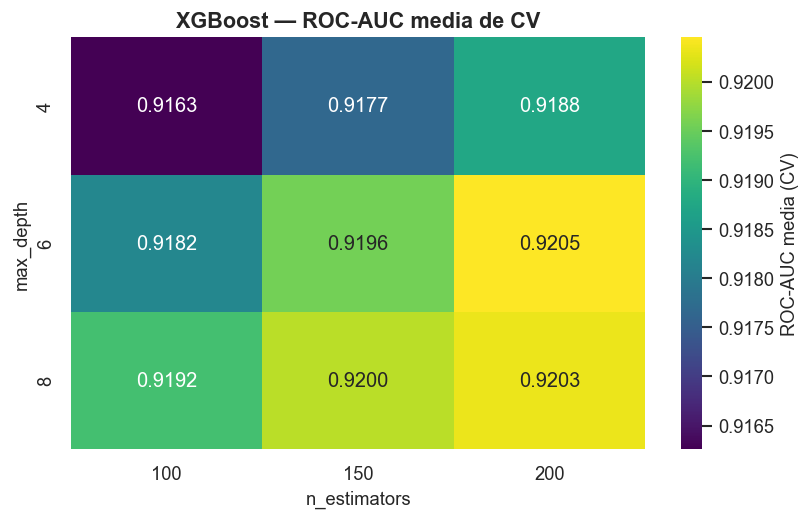

In [ ]:
# ── Heatmap — XGBoost ─────────────────────────────────────────────────────────
res_xgb = pd.DataFrame(gs_xgb.cv_results_)
pivot_xgb = res_xgb.pivot_table(index="param_max_depth", columns="param_n_estimators",
                                values="mean_test_score")
plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot_xgb, annot=True, fmt=".4f", cmap="viridis",
            cbar_kws={"label": "ROC-AUC media (CV)"})
plt.title("XGBoost — ROC-AUC media de CV", fontweight="bold")
plt.xlabel("n_estimators"); plt.ylabel("max_depth")
plt.tight_layout(); plt.show()

In [ ]:
# ── Tabla de resultados de GridSearchCV — XGBoost ─────────────────────────────
tbl_xgb = cv_results_table(gs_xgb, ["n_estimators", "max_depth"])
(tbl_xgb.style
    .format({"ROC-AUC media (CV)": "{:.4f}", "Desv. estándar": "{:.4f}"})
    .background_gradient(subset=["ROC-AUC media (CV)"], cmap="Blues")
    .set_caption("GridSearchCV — XGBoost (mejores combinaciones)")
    .hide(axis="index"))

n_estimators,max_depth,ROC-AUC media (CV),Desv. estándar,Rank
200,6,0.9205,0.0009,1
200,8,0.9203,0.0007,2
150,8,0.9200,0.0007,3
150,6,0.9196,0.0008,4
100,8,0.9192,0.0009,5
200,4,0.9188,0.0007,6
100,6,0.9182,0.0010,7
150,4,0.9177,0.0007,8


## 6. Evaluación Final de los Modelos Optimizados

Esta sección reúne la evaluación de los **tres modelos optimizados** (mejor combinación de `GridSearchCV` de cada algoritmo):

- **6.1** Curva **ROC-AUC promedio sobre entrenamiento** (promediada a través de los *folds*).
- **6.2** Curva **ROC-AUC final** a partir de **predicciones concatenadas OOF** (una sola curva por modelo, sin promediar).
- **6.3** **Matrices de confusión** de los modelos optimizados.
- **6.4** Tabla comparativa.

Primero se generan las predicciones *out-of-fold* que alimentan las secciones 6.2–6.4.

In [ ]:
# ── Predicciones OOF concatenadas (mejor estimador de cada modelo) ────────────
print("Generando predicciones out-of-fold (esto reentrena cada modelo por fold)...")

oof_lr  = cross_val_predict(gs_lr.best_estimator_,  X, y, cv=cv_strategy,
                            method="predict_proba", n_jobs=-1)[:, 1]
oof_rf  = cross_val_predict(gs_rf.best_estimator_,  X, y, cv=cv_strategy,
                            method="predict_proba", n_jobs=-1)[:, 1]
oof_xgb = cross_val_predict(gs_xgb.best_estimator_, X, y, cv=cv_strategy,
                            method="predict_proba", n_jobs=-1)[:, 1]

auc_lr  = roc_auc_score(y, oof_lr)
auc_rf  = roc_auc_score(y, oof_rf)
auc_xgb = roc_auc_score(y, oof_xgb)

print(f"ROC-AUC OOF — Logistic Regression : {auc_lr:.4f}")
print(f"ROC-AUC OOF — Random Forest       : {auc_rf:.4f}")
print(f"ROC-AUC OOF — XGBoost             : {auc_xgb:.4f}")

Generando predicciones out-of-fold (esto reentrena cada modelo por fold)...
ROC-AUC OOF — Logistic Regression : 0.9114
ROC-AUC OOF — Random Forest       : 0.9082
ROC-AUC OOF — XGBoost             : 0.9204


In [ ]:
# ── Etiquetas de hiperparámetros para la leyenda ──────────────────────────────
bp_lr, bp_rf, bp_xgb = gs_lr.best_params_, gs_rf.best_params_, gs_xgb.best_params_

hp_lr  = (f"degree={bp_lr['pre__num__poly__degree']}, C={bp_lr['logreg__C']}, "
          f"penalty={bp_lr['logreg__penalty']}")
hp_rf  = f"n_estimators={bp_rf['n_estimators']}, max_depth={bp_rf['max_depth']}"
hp_xgb = f"n_estimators={bp_xgb['n_estimators']}, max_depth={bp_xgb['max_depth']}"

opt_models = [
    ("Logistic Regression", gs_lr.best_estimator_,  oof_lr,  auc_lr,  hp_lr,  "#E8694C"),
    ("Random Forest",       gs_rf.best_estimator_,  oof_rf,  auc_rf,  hp_rf,  "#4C9BE8"),
    ("XGBoost",             gs_xgb.best_estimator_, oof_xgb, auc_xgb, hp_xgb, "#2ca02c"),
]
print("Etiquetas de modelos optimizados listas.")

Etiquetas de modelos optimizados listas.


### 6.1 Curva ROC-AUC Promedio sobre Entrenamiento (folds)

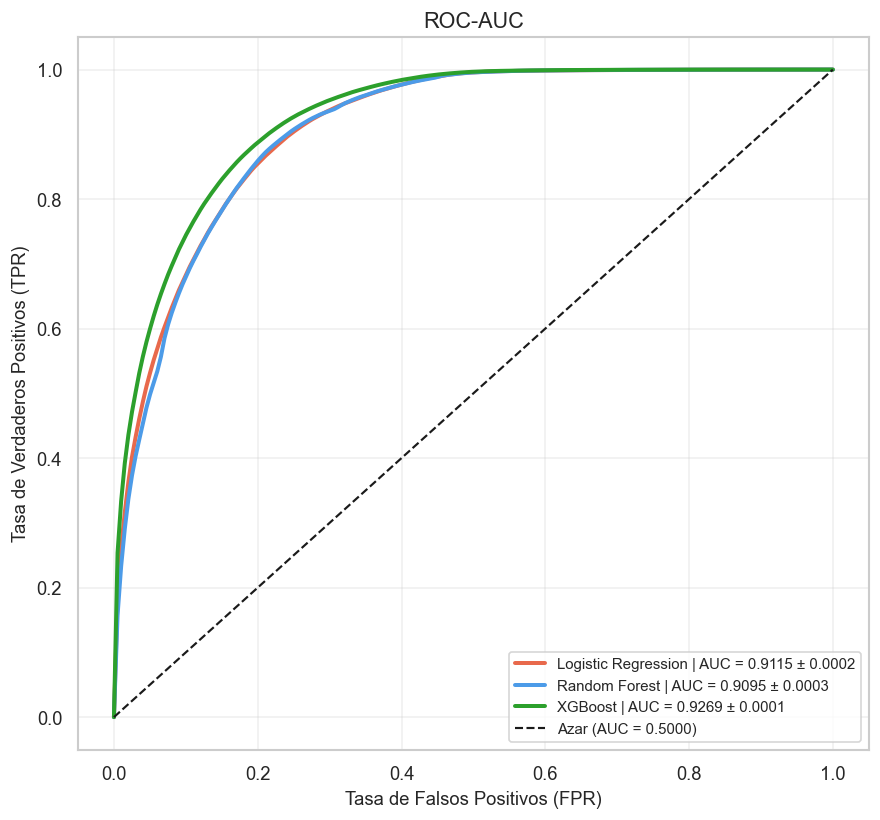

In [ ]:
mean_fpr = np.linspace(0, 1, 200)

def averaged_train_roc(estimator, X, y, cv):
    # Promedia la curva ROC de entrenamiento a través de los folds.
    tprs, aucs = [], []
    for tr_idx, _ in cv.split(X, y):
        est = clone(estimator).fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = est.predict_proba(X.iloc[tr_idx])[:, 1]
        fpr, tpr, _ = roc_curve(y.iloc[tr_idx], p)
        tpr_i = np.interp(mean_fpr, fpr, tpr); tpr_i[0] = 0.0
        tprs.append(tpr_i)
        aucs.append(roc_auc_score(y.iloc[tr_idx], p))
    mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
    return mean_tpr, np.mean(aucs), np.std(aucs)

plt.figure(figsize=(7.5, 7))
for name, est, _oof, _auc, hp, color in opt_models:
    mean_tpr, ma, sa = averaged_train_roc(est, X, y, cv_strategy)
    plt.plot(mean_fpr, mean_tpr, color=color, lw=2.4,
             label=f"{name} | AUC = {ma:.4f} ± {sa:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1.3, label="Azar (AUC = 0.5000)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("ROC-AUC")
plt.legend(loc="lower right", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 6.2 Curva ROC-AUC Final — Predicciones Concatenadas (OOF)

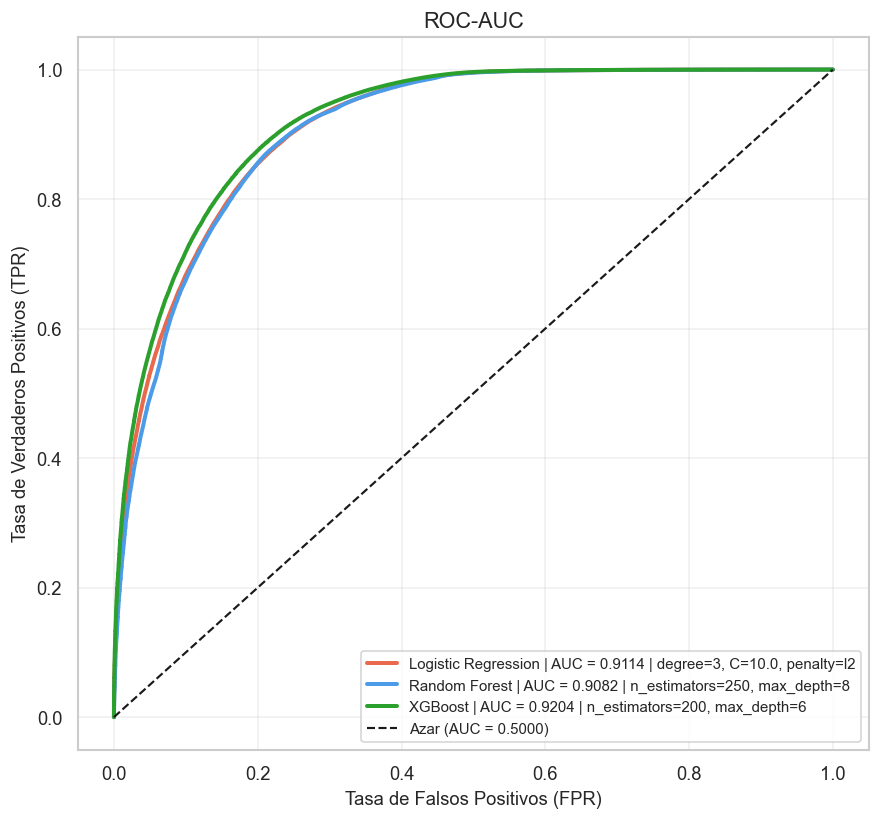

In [ ]:
plt.figure(figsize=(7.5, 7))
for name, _est, oof, auc_val, hp, color in opt_models:
    fpr, tpr, _ = roc_curve(y, oof)
    plt.plot(fpr, tpr, color=color, lw=2.4,
             label=f"{name} | AUC = {auc_val:.4f} | {hp}")
plt.plot([0, 1], [0, 1], "k--", lw=1.3, label="Azar (AUC = 0.5000)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("ROC-AUC")
plt.legend(loc="lower right", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 6.3 Matrices de Confusión — Modelos Optimizados

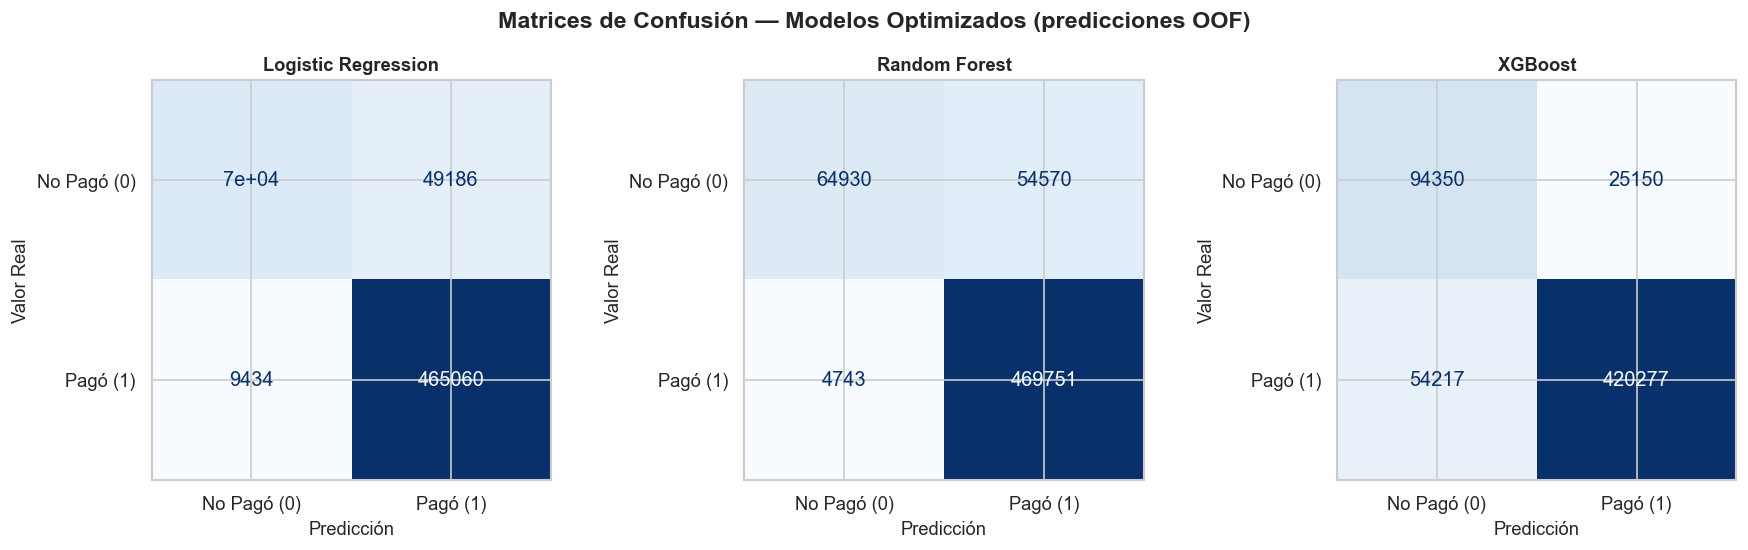

In [ ]:
# ── Matrices de confusión — modelos optimizados (predicciones OOF) ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, _est, oof, _auc, _hp, _c) in zip(axes, opt_models):
    y_pred = (oof >= 0.5).astype(int)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["No Pagó (0)", "Pagó (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold", fontsize=11)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor Real")
fig.suptitle("Matrices de Confusión — Modelos Optimizados (predicciones OOF)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 6.4 Tabla Comparativa Final

In [ ]:
# ── Tabla resumen profesional de los modelos optimizados ──────────────────────
summary = pd.DataFrame({
    "Modelo":            ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC (CV media)": [gs_lr.best_score_, gs_rf.best_score_, gs_xgb.best_score_],
    "ROC-AUC (OOF concat.)": [auc_lr, auc_rf, auc_xgb],
    "Mejores hiperparámetros": [hp_lr, hp_rf, hp_xgb],
}).sort_values("ROC-AUC (OOF concat.)", ascending=False).reset_index(drop=True)

(summary.style
    .format({"ROC-AUC (CV media)": "{:.4f}", "ROC-AUC (OOF concat.)": "{:.4f}"})
    .background_gradient(subset=["ROC-AUC (OOF concat.)"], cmap="Greens")
    .set_caption("Comparativa final de modelos optimizados")
    .hide(axis="index"))

Modelo,ROC-AUC (CV media),ROC-AUC (OOF concat.),Mejores hiperparámetros
XGBoost,0.9205,0.9204,"n_estimators=200, max_depth=6"
Logistic Regression,0.9114,0.9114,"degree=3, C=10.0, penalty=l2"
Random Forest,0.9083,0.9082,"n_estimators=250, max_depth=8"


## 7. Feature importance

In [ ]:
best_xgb = gs_xgb.best_estimator_

# Importancia normalizada por columna codificada
importance_encoded = pd.DataFrame({
    "Encoded_Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

# Features originales del problema
ORIGINAL_FEATURES = NUMERIC_CONT + ["grade_subgrade"] + CATEGORICAL_COLS

def map_to_original_feature(encoded_feature):
    for original_feature in ORIGINAL_FEATURES:
        if encoded_feature == original_feature:
            return original_feature
        if encoded_feature.startswith(original_feature + "_"):
            return original_feature
    return encoded_feature

# Mapear columnas one-hot a su variable original
importance_encoded["Original_Feature"] = importance_encoded["Encoded_Feature"].apply(
    map_to_original_feature
)

# Agrupar importancias por variable original
feature_importance = (
    importance_encoded
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# Normalizar nuevamente para que la suma sea 1
feature_importance["Importance"] = (
    feature_importance["Importance"] / feature_importance["Importance"].sum()
)

feature_importance.insert(0, "Rank", feature_importance.index + 1)

display(
    feature_importance.style
    .format({"Importance": "{:.3f}"})
    .background_gradient(subset=["Importance"], cmap="Blues")
    .set_caption("Importancia de Features - XGBoost")
    .hide(axis="index")
)



Rank,Original_Feature,Importance
1,employment_status,0.953
2,debt_to_income_ratio,0.016
3,credit_score,0.009
4,grade_subgrade,0.007
5,loan_purpose,0.006
6,education_level,0.003
7,marital_status,0.002
8,gender,0.002
9,loan_amount,0.001
10,annual_income,0.001


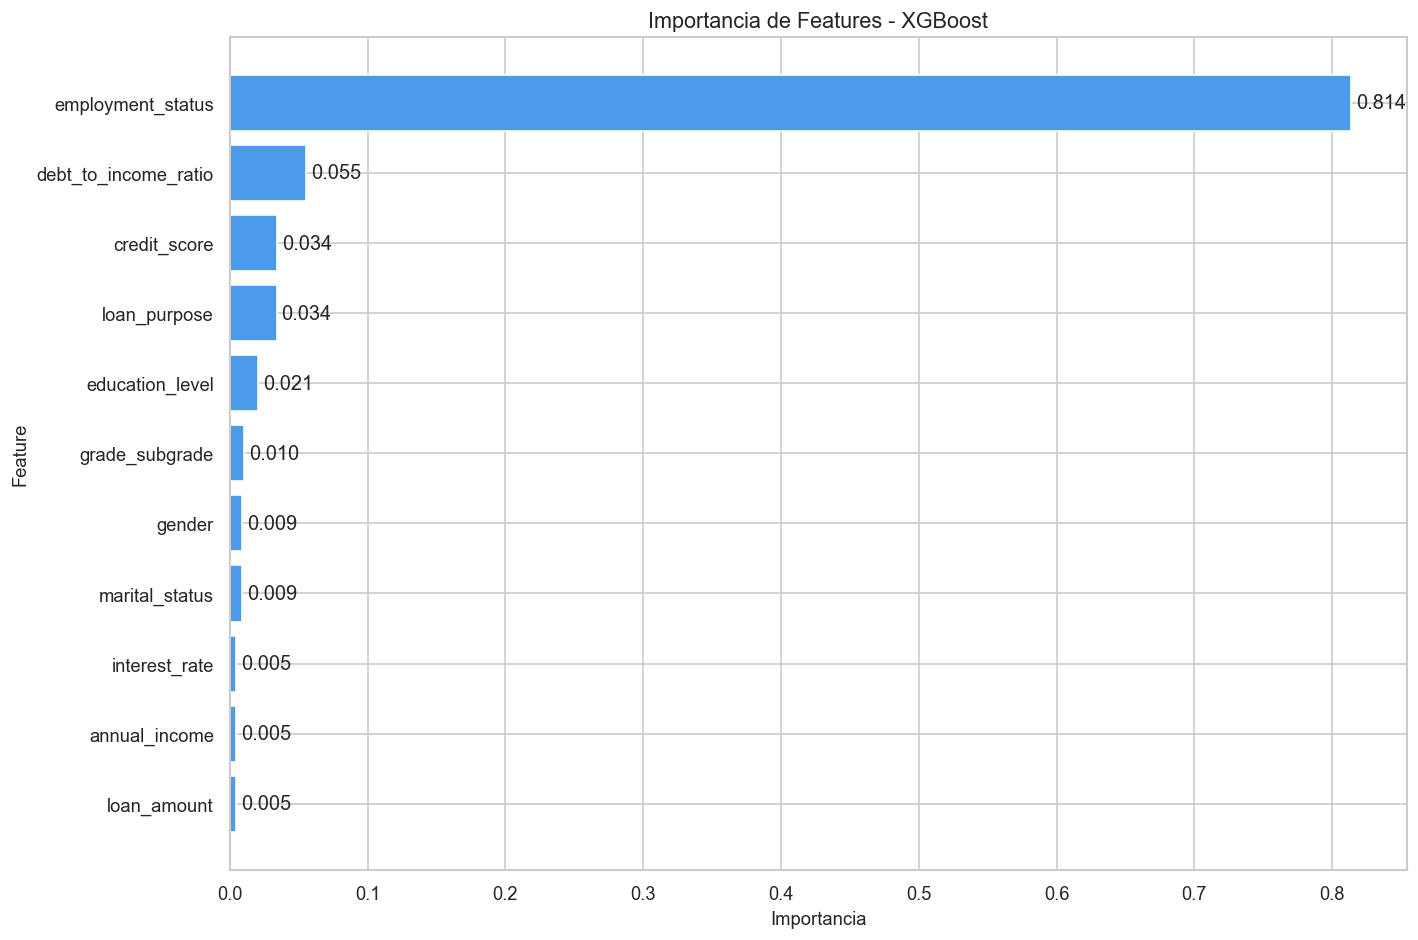

In [ ]:
plot_importance = feature_importance.sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    plot_importance["Original_Feature"],
    plot_importance["Importance"],
    color="#4C9BE8"
)

ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_title("Importancia de Features - XGBoost")
ax.set_xlabel("Importancia")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=600, bbox_inches="tight")
plt.show()


## 8. Interpretabilidad Local con SHAP

In [ ]:
explainer = shap.TreeExplainer(best_xgb)
proba_all = best_xgb.predict_proba(X)[:, 1]
obs_pos = int(np.argmin(np.abs(proba_all - 0.85)))   # caso con clara probabilidad de pagar
x_obs   = X.iloc[[obs_pos]]

sv = explainer(x_obs)                      
pred_class = int(best_xgb.predict(x_obs)[0])
pred_prob  = float(best_xgb.predict_proba(x_obs)[0, 1])
base_value = float(sv.base_values[0])
fx_value   = float(sv.values[0].sum() + base_value)

print(f"Observación analizada (índice posicional): {obs_pos}")
print(f"  Clase predicha        : {pred_class}  ({'Pagó' if pred_class==1 else 'No Pagó'})")
print(f"  Probabilidad predicha : {pred_prob:.4f}")
print(f"  Valor base  E[f(X)]   : {base_value:.4f}  (log-odds)")
print(f"  Salida      f(x)      : {fx_value:.4f}  (log-odds)")

# SHAP por columna codificada
contrib_encoded = (
    pd.DataFrame({
        "Encoded_Feature": x_obs.columns,
        "Valor": x_obs.iloc[0].values,
        "SHAP": sv.values[0]
    })
    .assign(
        Original_Feature=lambda d: d["Encoded_Feature"].apply(map_to_original_feature),
        Abs_SHAP=lambda d: d["SHAP"].abs()
    )
)

# Función para recuperar el valor observado en variables originales.
# En categóricas, devuelve la categoría activa de la dummy.
def get_observed_value(original_feature, row):
    if original_feature in NUMERIC_CONT or original_feature == "grade_subgrade":
        return row[original_feature]

    matching_cols = [
        col for col in row.index
        if col.startswith(original_feature + "_") and row[col] == 1
    ]

    if len(matching_cols) > 0:
        return matching_cols[0].replace(original_feature + "_", "")

    return "No activo"

# SHAP agrupado por variable original
contrib_original = (
    contrib_encoded
    .groupby("Original_Feature", as_index=False)
    .agg(
        SHAP=("SHAP", "sum"),
        Abs_SHAP=("SHAP", lambda x: np.abs(x).sum())
    )
    .sort_values("Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

contrib_original["Valor_observado"] = contrib_original["Original_Feature"].apply(
    lambda feature: get_observed_value(feature, x_obs.iloc[0])
)

contrib_original = contrib_original[[
    "Original_Feature", "Valor_observado", "SHAP", "Abs_SHAP"
]]

# Explanation agrupado para graficar SHAP con nombres de features originales
sv_grouped = shap.Explanation(
    values=contrib_original["SHAP"].values,
    base_values=base_value,
    data=None,
    feature_names=contrib_original["Original_Feature"].tolist()
)


Observación analizada (índice posicional): 4711
  Clase predicha        : 1  (Pagó)
  Probabilidad predicha : 0.8500
  Valor base  E[f(X)]   : -0.0104  (log-odds)
  Salida      f(x)      : 1.7346  (log-odds)


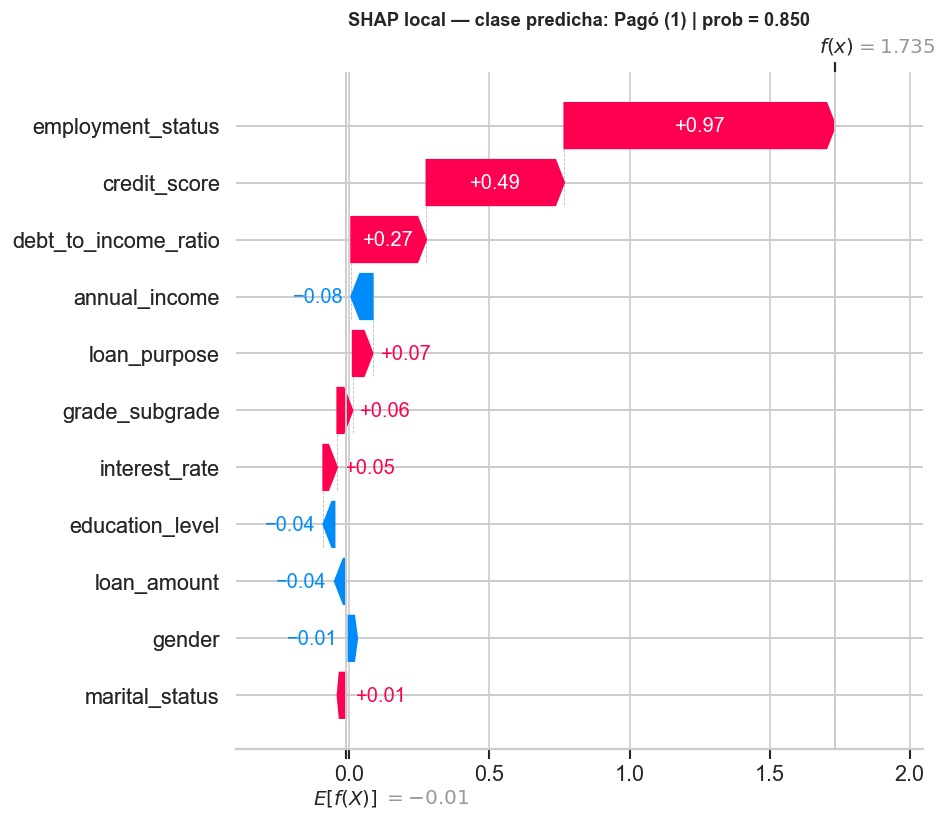

In [ ]:
# ── Gráfico waterfall SHAP agrupado por feature original ─────────────────────
shap.plots.waterfall(sv_grouped, max_display=11, show=False)
plt.title(
    f"SHAP local — clase predicha: {'Pagó (1)' if pred_class==1 else 'No Pagó (0)'} | prob = {pred_prob:.3f}",
    fontweight="bold",
    fontsize=11
)
plt.tight_layout()
plt.show()


## 9. Predicciones sobre el Conjunto de Prueba

In [ ]:
oof_aucs = {"Logistic Regression": (auc_lr, gs_lr.best_estimator_),
            "Random Forest":       (auc_rf, gs_rf.best_estimator_),
            "XGBoost":             (auc_xgb, gs_xgb.best_estimator_)}
best_name = max(oof_aucs, key=lambda k: oof_aucs[k][0])
best_auc, best_model = oof_aucs[best_name]
print(f"Mejor modelo global: {best_name}  (ROC-AUC OOF = {best_auc:.4f})")


final_prob  = best_model.predict_proba(X_test)[:, 1]
final_label = best_model.predict(X_test)

submission = pd.DataFrame({
    "id": test_df["id"],
    "loan_paid_back": final_label.astype(int),
    "loan_paid_back_prob": final_prob,
})
print(f"\nPredicciones generadas: {len(submission):,}")
print(f"  Pagará (1)    : {(submission['loan_paid_back']==1).sum():,} "
      f"({(submission['loan_paid_back']==1).mean()*100:.1f}%)")
print(f"  No pagará (0) : {(submission['loan_paid_back']==0).sum():,} "
      f"({(submission['loan_paid_back']==0).mean()*100:.1f}%)")
submission.head(10)

Mejor modelo global: XGBoost  (ROC-AUC OOF = 0.9154)

Predicciones generadas: 254,569
  Pagará (1)    : 192,039 (75.4%)
  No pagará (0) : 62,530 (24.6%)


,id,loan_paid_back,loan_paid_back_prob
0,593994,1,0.7871
1,593995,1,0.9407
2,593996,0,0.1647
3,593997,1,0.8268
4,593998,1,0.8534
5,593999,1,0.8586
6,594000,1,0.9470
7,594001,1,0.9024
8,594002,1,0.7313
9,594003,0,0.0031


In [ ]:
# ── Exportar predicciones ─────────────────────────────────────────────────────
submission[["id", "loan_paid_back"]].to_csv("predictions.csv", index=False)
submission.to_csv("predictions_with_probabilities.csv", index=False)
print("Archivos exportados:")
print("  predictions.csv                    (id + etiqueta)")
print("  predictions_with_probabilities.csv (id + etiqueta + probabilidad)")

Archivos exportados:
  predictions.csv                    (id + etiqueta)
  predictions_with_probabilities.csv (id + etiqueta + probabilidad)
